# PT1: Device Binding and Execution Modes

This notebook is the start of a three part series that goes into a deep dive inside `aether/layers/pooling.py` and `aether/custom_kernels/pooling_kernel.py`. 

The goal of this specific notebook is to explore how the parent class `_PoolNd` along with the help of the child class method `_compile_for_device(self, device):` abstracts GPU execution, and dynamically rebinding the forward/backward pass methods depending on the target hardware (HIP vs CUDA vs CPU) and training status (to keep or not keep `self.max_indices` during the forward pass for backward pass calculation)

## Overview of input preperation `_prepare_forward_input` and zero-pad allocation `_get_padded_input`

For this approach, we'll split up class `Pooling` and divide it into two seperate classes, `MaxPool2d` and `AvgPool2d`. Because both classes perform the same function for most things, we'll have a parent class `_PoolNd` have helper methods, this promotes the **DRY** principle and honestly makes the code easier to follow.

In [1]:
import sys
from pathlib import Path

# Path.cwd() is .../notebooks/implementation/pooling_final
root_dir = Path.cwd().parents[2] 

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from aether.layers.pooling import MaxPool2d

In [2]:
import numpy as np
import aether.config as config 
class _PoolNd(): # Layer is passed here, but for this notebook it is omitted
    def __init__(self):
        self._launch_cache = {}

    def _get_padded_input(self, H_in, W_in):
        fH, fW = self.filter_size
        sH, sW = self.stride

        if self.padding == "valid":
            H_out = int(np.floor((H_in - fH) / sH + 1).item())
            W_out = int(np.floor((W_in - fW) / sW + 1).item())

            pad_top, pad_bottom, pad_left, pad_right = 0, 0, 0, 0
        elif self.padding == "same":

            H_out = int(np.ceil(H_in / sH).item())
            W_out = int(np.ceil(W_in / sW).item())

            pad_h = max((H_out - 1) * sH + fH - H_in, 0)
            pad_w = max((W_out - 1) * sW + fW - W_in, 0)
            pad_top = pad_h // 2
            pad_bottom = pad_h - pad_top
            pad_left = pad_w // 2
            pad_right = pad_w - pad_left
        else:
            raise ValueError(f"Expected padding == valid or same, recieved {self.padding} instead")
        return H_out, W_out, pad_top, pad_bottom, pad_left, pad_right
    
    def _prepare_forward_input(self, inputs, pad_value):
        """Shared shape validation + padding for pooling forward passes.
        pad_value differs by pooling type: -inf for max, 0.0 for average."""
        xp = config.get_array_module(inputs)
        if inputs.ndim != 4:
            raise ValueError(f"Expected a 4D tensor, recieved {inputs.ndim}D tensor instead")

        inputs = inputs.astype(xp.float32, copy=False)
        S, H_in, W_in, C = inputs.shape
        H_out, W_out, pad_top, pad_bottom, pad_left, pad_right = self._get_padded_input(H_in, W_in)

        self.pad_top, self.pad_bottom = pad_top, pad_bottom
        self.pad_left, self.pad_right = pad_left, pad_right

        if self.padding == "valid":
            inputs_padded = inputs
        elif self.padding == "same":
            inputs_padded = xp.pad(
                inputs,
                ((0, 0), (pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
                mode='constant',
                constant_values=pad_value,
            )
        else:
            raise ValueError(f"Expected padding == valid or same, recieved {self.padding} instead")

        inputs_padded = xp.ascontiguousarray(inputs_padded)
        return xp, inputs_padded, S, H_out, W_out


## How does _perpare_forward_input() work? 

This layer handles the forward input for all four forward branches of the pooling layers. We include a pointer to are inputs tensor `inputs` alogn with a value `pad_value` that pads our tensor with `pad_value`. In the forward max pooling pass, 
* Max Pooling: if we have a window $fH x fW$ and the highest value is $-5.3$ inside the window, then a padded value $0.0$ would incorrectly map the winning element to the padded value, and not our correct value. To combat this, all padded values will have `-np.inf` preventing this logical error. 
* Average Pooling: To avoid having the padded values polute our caluclations inside a $fH x fW$ window, each padded element is set to zero. That means, if inside the if branch:

    * `"valid"`:  we imply that we don't want to perserve the spatial dimensions after the calculation, if we have a $8x8$ input, a kernel $K = 3x3$ and stride $s = 2x2$. Then the kernel slides across (by row) $0,1,2$ $2,3,4$ $4,5,6$ $6,7,8$ At the last stride, we can't reach pixel 8 in a $8x8$ image so we have to truncate that last pad, and move to the next row. 
    * `same`:  we imply that we would like to pad the area by a set amount to preserve our actual window values. In the earlier example, we'd pad each side a padding formula, then use integer divsion to set the amount of padding on each side. 

For the most part, with non-overlapping kernels $fHxfW = sHxsW$, we can set to valid. We might still set to `same` if we have a strict architectural shape target. 

Finally, because the fallback paths for the pooling layers and the convolutional layers use non-contiguous arrays, we set the tensor to a contiguousarray before continuing. If we avoided this condition our kernels would perform a copy of the tensor in VRAM slowing down calculations. 


## Hardware Target Detection & Compilation 
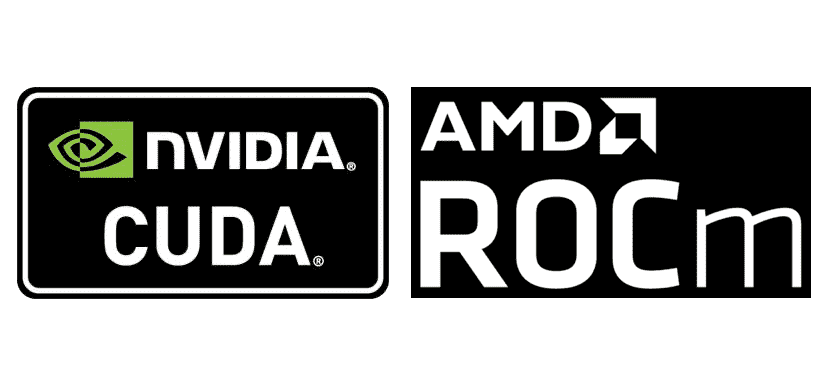

In this part, all the user has to call is `Model.to(device = 'cupy' or 'hip')`
Then, for each layer that we have setup after `Model.add`, we'll call each layers `_compile_for_device` method. Both average pooling and max pooling have quite similar `_compile_for_device` methods, but Max pooling includes a seperate branch whether or not the user is training or not:

In [3]:
from functools import partial
from aether.custom_kernels import pooling_kernel as gpu_pooling

class MaxPool2d_ex(_PoolNd):
    def _compile_for_device(self, device):
        """Triggered by Model.to(device) to map low-level hardware paths."""
        if device == 'cupy' and gpu_pooling.is_gpu_max_pool2d_available():
            is_hip = config.HAS_CUPY and config.xp.cuda.runtime.is_hip
            self._variant = "hip" if is_hip else "cuda"

            # Block depth of 2 is recommended for HIP
            # Block depth of 4 is recommended for CUDA
            self._block_z = 2 if is_hip else 4

            self._kernel_train = gpu_pooling.get_max_pool2d_forward_kernel(
                self._variant, training=True
            )
            self._kernel_infer = gpu_pooling.get_max_pool2d_forward_kernel(
                self._variant, training=False
            )

            self._kernel_backward_nonoverlap = gpu_pooling.get_max_pool2d_backward_kernel(
                self._variant
            )

            self.forward = partial(self._forward_gpu, block_z=self._block_z)
            self.backward = partial(self._backward_gpu, block_z=self._block_z)
        else:
            self.forward = self._forward_fallback
            self.backward = self._backward_fallback

This part should be straight forwrad to understand. We can talk about the else branch first though. 
* `else`: Here, if the user does not have CuPy installed, we'll automatically reach for the standard vectorized fallback paths. 

Now, for the first boolean `if device == 'cupy' ...`. Here, we check that the user wrote `cupy`, and the flag `HAS.CUPY` is checked inside `aether.config`. 
```python
config.HAS_CUPY and config.xp.cuda.runtime.is_hip 
```
This rechecks the earlier condition, and uses a high level built in boolean method from cupy that confirms if the user is running hip. 
```python
self._block_z = 2 if is_hip else 4

#Later on in the code
block_x = min(32, C)
block_y = 8
block_dim = (block_x, block_y, block_z)
```

We've actually already brought up memory transactions transactions before, but we'll bring up a small refresher nonetheless. 
GPUs execute small groups of threads in lockstep using Single Instruction, Multiple Threads (SIMT). The sources for this can be found with links below: 

* CUDA: Executes threads in groups of 32 https://docs.nvidia.com/cuda/cuda-programming-guide/05-appendices/compute-capabilities.html
    * EX 1: 32-bit (4-byte) Float data: If each of the 32 threads in a warp requests one standard 32-bit floating-point variable (`float32`=4bytes):
        1. Total requested data: $32 \text{ threads} \times 4 \text{ bytes/thread} = \mathbf{128 \text{ bytes}}$.
        2. Thus, the GPU memory controller sends the whole warp request in **one single 128-byte memory transaction.**
    * EX 2: (8-bit / 1bytye uint8 data): If each of the 32 threads in a warp requests one `uint8` (1 byte): 
        1. Total requested data = $32 \text{ threads} \times 1 \text{ byte/thread} = \mathbf{32 \text{ bytes}}$.
        2. This GPU serives the entire request in **one single 32-byte transaction.**
            * Note: In practice, 32 threads loading 4 bytes each (`uint32` or `uint8x4` vector) would load $4\times$ more elements in 1 memory request. Filling a memory buffer in both sides (CUDA and HIP) will result in higher effective bandwidth. 
* ROCM/HIP: Executes threads in groups of 32 (for non CDNA architectures) and groups of 64 for CDNA. For the exact size, the table found at https://rocm.docs.amd.com/en/latest/reference/gpu-specs.html provides a useful table.
    * EX 1: 32 threads read a sinngle 4-byte `float32` element from a contiguous array:
        1. The total requested data: $32 \text{ threads} \times 4 \text{ bytes/thread} = \mathbf{128 \text{ bytes}}$
        2. We still have 100% effective bus utilitzation like in CUDA.
    * EX 2: Vectorized `float4` (16 bytes) pass where each thread reads 4 floats at once. Since we still have 32 threads:
        1. Total requested data: $32 \text{ threads} \times 16 \text{ bytes/thread} = \mathbf{512 \text{ bytes}}$
        2. Even though it requires 4 physical memory transaction, we still perform the operation in a single hardware load instruction. We still saturate the memory buff while reducing the overhead from generating new instructions. 

The last example is likely the most important thing to take away from this notebook. We'll find out that even though we will require multiple memory transactions to do an operation, the way we write the kernel will mean that we carry the overhead (a single load instruction) for the price of **many** memory transactions. 

### Connecting the Memory and Thread Examples back to the Block Dimensions

Assume when we run the kernel that it is contiguous because we run `xp.ascontiguousarray(input_tensor, copy=False)`: 
1. `block_x = min(32, C)`: Every adjacent thread IDs in the fastest dimension map directly to adjacent memory addresses, enabling coalsced 128-byte memory reads. 
2. `block_z = 2 if is_hip else 4`: Adjusts the total threads per block (1024 for CUDA vs 512 for HIP). Halving $z$ to 2 reduces the register pressure per Compute Unit while ensuring total block threads remain a clean multiple of the wavefront size (32 or 64).
    * For AMD users, a script is below that shows the difference in total thread count for _block_z, I have decided to leave it as 2 for users with older Radeon hardware. 

$$\text{Total Threads} = \text{block\_x} \times \text{block\_y} \times \text{block\_z}$$
On CUDA, if $x=32$ and $z=4$ we choose $y=8$ to scale the total block size up to the **1024 thread limit**.
On HIP, the same issue arrises, our sweat spot this time is **512 threads per block**, so we'll keep $y=8$.

In [4]:
from functools import partial
import time
import numpy as np

import aether.config as config
from aether.layers.pooling import MaxPool2d

In [5]:
BATCH        = 32
H_IN, W_IN   = 128, 128
CHANNELS     = 32

FILTER_SIZE  = (2, 2)
STRIDE       = (2, 2)
PADDING      = 'same'

WARMUP_ITERS = 10
TIMED_ITERS  = 200

def sync():
    """Synchronize GPU execution stream before timing."""
    if config.HAS_CUPY:
        config.xp.cuda.Stream.null.synchronize()

def make_input():
    xp = config.xp
    rng = xp.random.RandomState(0)
    return rng.randn(BATCH, H_IN, W_IN, CHANNELS).astype(xp.float32)

def set_layer_block_z(layer, block_z: int):
    """Mutates block_z and re-binds the forward/backward partials directly

    without re-running _compile_for_device() (which hardcodes block_z).
    """
    layer._block_z = block_z
    layer.forward = partial(layer._forward_gpu, block_z=block_z)
    layer.backward = partial(layer._backward_gpu, block_z=block_z)

def bench_forward_backward(layer, inputs, label):
    xp = config.xp

    # --- Warmup: allow JIT kernel compilation and stream settling
    for _ in range(WARMUP_ITERS):
        out = layer.forward(inputs, training=True)
        dvalues = xp.ones_like(out)
        layer.backward(dvalues)
    sync()

    # --- Timed Forward Pass
    start = time.perf_counter()
    for _ in range(TIMED_ITERS):
        out = layer.forward(inputs, training=True)
    sync()
    fwd_elapsed = time.perf_counter() - start

    dvalues = xp.ones_like(out)

    # --- Timed Backward Pass
    start = time.perf_counter()
    for _ in range(TIMED_ITERS):
        layer.backward(dvalues)
    sync()
    bwd_elapsed = time.perf_counter() - start

    fwd_ms = (fwd_elapsed / TIMED_ITERS) * 1000
    bwd_ms = (bwd_elapsed / TIMED_ITERS) * 1000
    total_ms = fwd_ms + bwd_ms

    print(f"[{label}] block_z={layer._block_z:d} | "
          f"Forward: {fwd_ms:.4f} ms | "
          f"Backward: {bwd_ms:.4f} ms | "
          f"Total: {total_ms:.4f} ms")

    return fwd_ms, bwd_ms, total_ms

def main():
    config.set_backend('cupy')
    xp = config.xp

    if not (config.HAS_CUPY and xp.cuda.runtime.is_hip):
        raise RuntimeError(
            "This benchmark requires a ROCm/HIP device with CuPy configured."
        )

    inputs = make_input()
    max_pool = MaxPool2d(filter_size=FILTER_SIZE, stride=STRIDE, padding=PADDING)
    
    # Initial hardware compilation (defaults to block_z=2 on HIP)
    max_pool._compile_for_device(device='cupy')

    is_overlap = FILTER_SIZE[0] > STRIDE[0] or FILTER_SIZE[1] > STRIDE[1]
    print(f"Window configuration : {'OVERLAPPING' if is_overlap else 'NON-OVERLAPPING'}")
    print(f"Detected GPU Variant : {max_pool._variant}")
    print(f"Input Shape          : {inputs.shape}\n" + "-" * 65)

    # --- Benchmark 1: block_z = 2 ---
    set_layer_block_z(max_pool, block_z=2)
    assert max_pool._block_z == 2
    fwd_2, bwd_2, total_2 = bench_forward_backward(max_pool, inputs, label="Run 1 (block_z=2)")

    # --- Benchmark 2: block_z = 4 ---
    set_layer_block_z(max_pool, block_z=4)
    assert max_pool._block_z == 4
    fwd_4, bwd_4, total_4 = bench_forward_backward(max_pool, inputs, label="Run 2 (block_z=4)")

    # --- Summary Comparison ---
    print("-" * 65)
    speedup = ((total_2 - total_4) / total_2) * 100
    if speedup > 0:
        print(f"Result: block_z=4 is {abs(speedup):.2f}% FASTER than block_z=2.")
    else:
        print(f"Result: block_z=2 is {abs(speedup):.2f}% FASTER than block_z=4.")

if __name__ == "__main__":
    main()

Window configuration : NON-OVERLAPPING
Detected GPU Variant : hip
Input Shape          : (32, 128, 128, 32)
-----------------------------------------------------------------
[Run 1 (block_z=2)] block_z=2 | Forward: 0.4110 ms | Backward: 0.2356 ms | Total: 0.6466 ms
[Run 2 (block_z=4)] block_z=4 | Forward: 0.4030 ms | Backward: 0.2397 ms | Total: 0.6426 ms
-----------------------------------------------------------------
Result: block_z=4 is 0.61% FASTER than block_z=2.


### One Final Thing, How we avoid unecessary work during MaxPool2d.forward_gpu_common(): 

Inside the code, we have two custom kernels `_MAX_OP` and `_MAX_OP_INFERENCE` that both use the template `_POOL_FORWARD_TEMPLATE`. On a high level, the 4D $(S, H, W, C)$ tensor `self.max_indices` is created to easily calculate `dinputs` during the backwards pass during our forward input. 

The issue is we actually can omit large tensor during inference, as either way we would like inference to be as fast as possible. Using `_MAX_OP_INFERENCE` skips this write back call. Another skip is shown below, the major thing is the memory savings, giving us more freedom to make our actual models larger in the real world. 

In [10]:
BATCH        = 64
H_IN, W_IN   = 256, 256
CHANNELS     = 64

FILTER_SIZE  = (2, 2)
STRIDE       = (2, 2)
PADDING      = 'same'

WARMUP_ITERS = 10
TIMED_ITERS  = 200

def sync():
    """Synchronize GPU execution stream before timing."""
    if config.HAS_CUPY:
        config.xp.cuda.Stream.null.synchronize()

def make_input():
    xp = config.xp
    rng = xp.random.RandomState(0)
    return rng.randn(BATCH, H_IN, W_IN, CHANNELS).astype(xp.float32)

def measure_peak_memory_mb(func):
    """Measures maximum VRAM reserved by the CuPy memory pool during execution."""
    if not config.HAS_CUPY:
        return 0.0
    
    pool = config.cp.get_default_memory_pool()
    
    pool.free_all_blocks()
    
    baseline_bytes = pool.total_bytes()
    
    func()
    sync()
    
    # Total bytes reserved by the allocator now reflects the maximum memory 
    # required at the highest point of intermediate creation
    peak_bytes = pool.total_bytes()
    
    pool.free_all_blocks()
    
    return max(0.0, (peak_bytes - baseline_bytes) / (1024 ** 2))

def bench_forward_mode(layer, inputs, training: bool, label: str):
    xp = config.xp

    # --- Warmup: allow JIT kernel compilation and stream settling
    for _ in range(WARMUP_ITERS):
        out = layer.forward(inputs, training=training)
    sync()

    # --- Measure Peak VRAM Memory
    peak_mem_mb = measure_peak_memory_mb(lambda: layer.forward(inputs, training=training))

    # --- Timed Forward Pass
    start = time.perf_counter()
    for _ in range(TIMED_ITERS):
        out = layer.forward(inputs, training=training)
    sync()
    fwd_elapsed = time.perf_counter() - start

    fwd_ms = (fwd_elapsed / TIMED_ITERS) * 1000

    print(f"[{label}] Mode: {'Training (_MAX_OP)' if training else 'Inference (_MAX_OP_INFERENCE)'} | "
          f"Forward: {fwd_ms:.4f} ms | "
          f"Peak VRAM: {peak_mem_mb:.2f} MB")

    return fwd_ms, peak_mem_mb

def bench_forward_fallback(layer, inputs, training: bool, label: str):
    xp = config.xp

    # Temporarily force layer back to fallback execution
    layer.forward = partial(layer._forward_fallback)

    # --- Warmup
    for _ in range(WARMUP_ITERS):
        out = layer.forward(inputs, training=training)
    sync()

    # --- Measure Peak VRAM Memory (captures transient as_strided/argmax buffers)
    peak_mem_mb = measure_peak_memory_mb(lambda: layer.forward(inputs, training=training))

    # --- Timed Forward Pass
    start = time.perf_counter()
    for _ in range(TIMED_ITERS):
        out = layer.forward(inputs, training=training)
    sync()
    fwd_elapsed = time.perf_counter() - start
    fwd_ms = (fwd_elapsed / TIMED_ITERS) * 1000

    print(f"[{label}] Mode: Training (_forward_fallback)             | "
          f"Forward: {fwd_ms:.4f} ms | "
          f"Peak VRAM: {peak_mem_mb:.2f} MB")

    return fwd_ms, peak_mem_mb

def main():
    config.set_backend('cupy')
    xp = config.xp

    if not config.HAS_CUPY:
        raise RuntimeError("This benchmark requires a GPU backend configured with CuPy.")

    inputs = make_input()
    max_pool = MaxPool2d(filter_size=FILTER_SIZE, stride=STRIDE, padding=PADDING)
    
    # Initialize GPU hardware kernels
    max_pool._compile_for_device(device='cupy')

    print(f"Detected GPU Variant : {max_pool._variant}")
    print(f"Input Shape          : {inputs.shape}\n" + "-" * 85)

    # --- Benchmark 1: Fused Kernel Training Forward Pass (_MAX_OP) ---
    fwd_train_ms, mem_train_mb = bench_forward_mode(
        max_pool, inputs, training=True, label="Run 1"
    )

    # --- Benchmark 2: Fused Kernel Inference Forward Pass (_MAX_OP_INFERENCE) ---
    fwd_infer_ms, mem_infer_mb = bench_forward_mode(
        max_pool, inputs, training=False, label="Run 2"
    )

    # --- Benchmark 3: Array-Strided Fallback Pass (_forward_fallback) ---
    fwd_fallback_ms, mem_fallback_mb = bench_forward_fallback(
        max_pool, inputs, training=True, label="Run 3"
    )

    # --- Summary Comparison ---
    print("-" * 85)
    speedup = ((fwd_train_ms - fwd_infer_ms) / fwd_train_ms) * 100
    mem_saved_mb = mem_train_mb - mem_infer_mb

    print("--- INFERENCE OPTIMIZATION (Fused Kernel Train vs. Fused Kernel Infer) ---")
    print(f"Speed Improvement: Inference is {speedup:.2f}% FASTER than Training forward pass.")
    print(f"Peak VRAM Saved  : {mem_saved_mb:.2f} MB saved by omitting argmax index tracking buffer.")

    kernel_speedup = ((fwd_fallback_ms - fwd_train_ms) / fwd_fallback_ms) * 100
    kernel_mem_saved_mb = mem_fallback_mb - mem_train_mb

    print("\n--- KERNEL FUSION BENEFIT (Fallback vs. Fused Kernel Train) ---")
    print(f"Speed Improvement: Custom Fused Kernel is {kernel_speedup:.2f}% FASTER than fallback.")
    print(f"Peak VRAM Saved  : Saved {kernel_mem_saved_mb:.2f} MB of transient VRAM allocations during forward pass.")
    
if __name__ == "__main__":
    main()

Detected GPU Variant : hip
Input Shape          : (64, 256, 256, 64)
-------------------------------------------------------------------------------------
[Run 1] Mode: Training (_MAX_OP) | Forward: 6.5378 ms | Peak VRAM: 0.00 MB
[Run 2] Mode: Inference (_MAX_OP_INFERENCE) | Forward: 6.0485 ms | Peak VRAM: 0.00 MB
[Run 3] Mode: Training (_forward_fallback)             | Forward: 183.5049 ms | Peak VRAM: 4352.00 MB
-------------------------------------------------------------------------------------
--- INFERENCE OPTIMIZATION (Fused Kernel Train vs. Fused Kernel Infer) ---
Speed Improvement: Inference is 7.49% FASTER than Training forward pass.
Peak VRAM Saved  : 0.00 MB saved by omitting argmax index tracking buffer.

--- KERNEL FUSION BENEFIT (Fallback vs. Fused Kernel Train) ---
Speed Improvement: Custom Fused Kernel is 96.44% FASTER than fallback.
Peak VRAM Saved  : Saved 4352.00 MB of transient VRAM allocations during forward pass.


One tine thing to note about the fallback path. The intermediate operations using `as_strided`, `argmax(axis = 3)`, and `unravel_index` all force massive temporary arrays and views. It was obvious this result would balloon worse then the other results with simpler layers such as `Leaky_ReLU` or `SoftMax.forward` as there are less operations and simpler temporary operations. In this case, we reap the reward of performing all calculations directly inside the Cache and GPU registers. This does technically show a limitation of using CuPy for using these types of layers, but still, having `cupy.RawKernel` shows a phenominal improvement. 

A FINAL FINAL thing to note, while this is fast, I believe that the compilers used in frameworks like PyTorch and Triton use algorithms to fuse these kernels even further, which is why their implementations will typically be much faster then even the ones shown here. 